# Notebook 01bis — Tests d'hypothèses statistiques

## Objectif

Valider scientifiquement les observations visuelles du notebook 01 par des tests statistiques. Chaque conclusion retenue pour le ML devra être soutenue par une p-value.

## Tests prévus

| Test | Variables | Hypothèse nulle H₀ | Utilité |
|---|---|---|---|
| **Shapiro-Wilk** | Capteurs numériques | La distribution est normale | Choisir entre test paramétrique (t-test) et non-paramétrique (Mann-Whitney) |
| **Khi²** | Type × Machine failure | Type et Machine failure sont indépendants | Confirmer/infirmer l'effet de la gamme sur le rebut |
| **t-test / Mann-Whitney U** | Capteurs × Machine failure | Les moyennes sont égales OK vs Panne | Identifier les capteurs discriminants |
| **ANOVA / Kruskal-Wallis** | Capteurs × Type | Les moyennes sont égales L vs M vs H | Valider la segmentation par gamme |
| **Spearman** | Corrélations monotones | Pas de corrélation | Complément à Pearson (plus robuste) |

## Rattachement grille MSPR

| Compétence | Critère |
|---|---|
| C4 — Modèles statistiques | Interpréter les résultats à l'écrit |
| C8 — Qualité des données | Valider scientifiquement les patterns |

## Seuil retenu

α = 0.05 (standard scientifique). Avec ~10 000 observations, la puissance statistique est élevée : il faut aussi regarder la **taille de l'effet** (Cohen's d, V de Cramér) et pas seulement la p-value.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/raw/ai4i2020.csv")

# Cast numerique (comme dans notebook 01)
sensor_cols = ["Air temperature [K]", "Process temperature [K]",
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Type"] = df["Type"].astype(str).str.strip().str.upper()
df = df[df["Type"].isin(["L", "M", "H"])].copy()

print(f"Shape apres nettoyage minimal : {df.shape}")


Shape apres nettoyage minimal : (10070, 14)


## 2. Test de normalité (Shapiro-Wilk)

**H₀** : la distribution de la variable est normale.
Si **p < 0.05** → on rejette H₀ → distribution **non normale** → on utilisera des tests non-paramétriques (Mann-Whitney plutôt que t-test).


In [2]:
rows = []
for col in sensor_cols:
    # Shapiro-Wilk limite a 5000 observations → on echantillonne
    sample = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stat, pval = stats.shapiro(sample)
    rows.append({"variable": col, "statistique": round(stat, 4),
                 "p_value": f"{pval:.2e}",
                 "normalite": "non" if pval < 0.05 else "oui"})

pd.DataFrame(rows)

,variable,statistique,p_value,normalite
0,Air temperature [K],0.0814,7.51e-94,non
1,Process temperature [K],0.0334,4.74e-95,non
2,Rotational speed [rpm],0.0293,3.78e-95,non
3,Torque [Nm],0.4667,1.51e-81,non
4,Tool wear [min],0.9591,2.43e-35,non


## 3. Test du Khi² : Type × Machine failure

**Question métier** : le taux de panne dépend-il de la gamme de pièce (L/M/H) ?
**H₀** : Type et Machine failure sont indépendants.


In [3]:
tab = pd.crosstab(df["Type"], df["Machine failure"])
print("Table de contingence :")
print(tab)
print()

chi2, pval, dof, expected = stats.chi2_contingency(tab)
n = tab.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

print(f"Chi2          : {chi2:.3f}")
print(f"p-value       : {pval:.2e}")
print(f"V de Cramer   : {cramer_v:.3f}  (effect size)")
print(f"Conclusion    : {'H0 rejetee (dependance)' if pval < 0.05 else 'H0 non rejetee'}")

Table de contingence :
Machine failure     0    1
Type                      
H                 989   21
L                5799  242
M                2926   93

Chi2          : 12.035
p-value       : 2.44e-03
V de Cramer   : 0.035  (effect size)
Conclusion    : H0 rejetee (dependance)


## 4. Comparaison capteurs : OK vs Panne

Pour chaque capteur, on compare la distribution sur les pièces OK et les pièces en panne.
Comme les distributions ne sont pas toutes normales (voir §2), on utilise le **Mann-Whitney U** (test non-paramétrique).

**H₀** : les distributions sont identiques entre OK et Panne.


In [4]:
rows = []
for col in sensor_cols:
    ok = df[df["Machine failure"] == 0][col].dropna()
    ko = df[df["Machine failure"] == 1][col].dropna()
    stat, pval = stats.mannwhitneyu(ok, ko, alternative="two-sided")

    # Effect size : Cliff's delta approximation
    n1, n2 = len(ok), len(ko)
    cliff = (2 * stat - n1 * n2) / (n1 * n2)

    rows.append({
        "capteur": col,
        "median_OK": round(ok.median(), 2),
        "median_PANNE": round(ko.median(), 2),
        "U_stat": int(stat),
        "p_value": f"{pval:.2e}",
        "cliff_delta": round(cliff, 3),
        "significatif": "oui" if pval < 0.05 else "non"
    })

pd.DataFrame(rows).sort_values("capteur")

,capteur,median_OK,median_PANNE,U_stat,p_value,cliff_delta,significatif
0,Air temperature [K],300.0,301.40,1211616,1.99e-15,-0.252,oui
1,Process temperature [K],310.0,310.50,1408707,1.24e-05,-0.138,oui
2,Rotational speed [rpm],1507.0,1366.50,2473012,7.84e-57,0.501,oui
4,Tool wear [min],107.0,161.00,1103528,3.84e-22,-0.309,oui
3,Torque [Nm],39.9,52.95,817833,3.63e-57,-0.502,oui


## 5. ANOVA / Kruskal-Wallis : capteurs × Type

**Question métier** : les paramètres machine diffèrent-ils selon la gamme de pièce ?
On utilise **Kruskal-Wallis** (équivalent non-paramétrique de l'ANOVA).

**H₀** : les médianes sont identiques entre L, M et H.


In [5]:
rows = []
for col in sensor_cols:
    groups = [df[df["Type"] == t][col].dropna() for t in ["L", "M", "H"]]
    stat, pval = stats.kruskal(*groups)
    rows.append({
        "capteur": col,
        "H_stat": round(stat, 2),
        "p_value": f"{pval:.2e}",
        "significatif": "oui" if pval < 0.05 else "non"
    })

pd.DataFrame(rows)

,capteur,H_stat,p_value,significatif
0,Air temperature [K],4.83,8.94e-02,non
1,Process temperature [K],4.20,1.22e-01,non
2,Rotational speed [rpm],0.45,7.99e-01,non
3,Torque [Nm],0.11,9.47e-01,non
4,Tool wear [min],0.85,6.53e-01,non


## 6. Corrélations de Spearman (monotones)

Complément à la corrélation de Pearson du notebook 01. Spearman détecte aussi les relations monotones non linéaires.


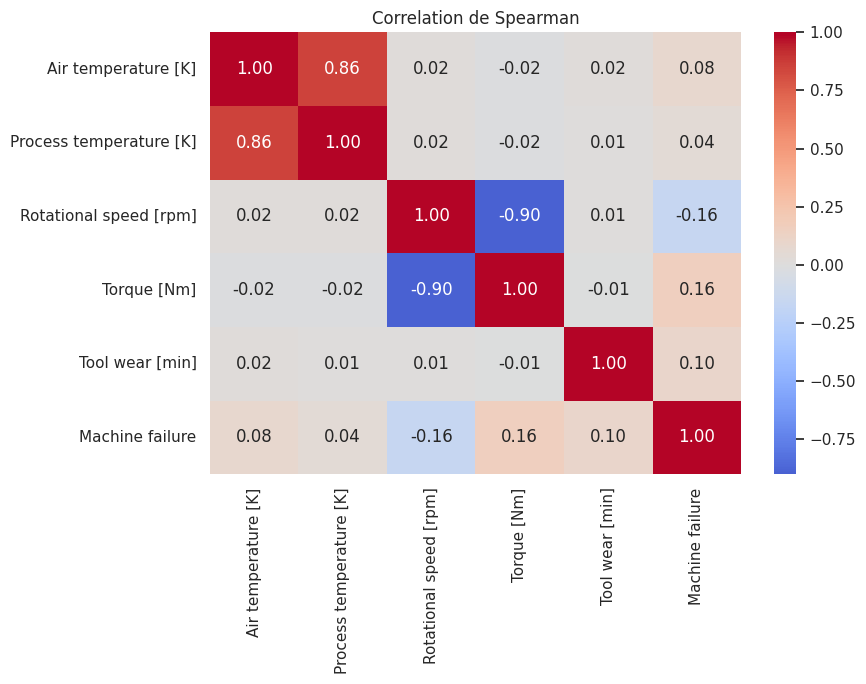

Top correlations de Spearman avec Machine failure :
Torque [Nm]                0.161
Rotational speed [rpm]    -0.160
Tool wear [min]            0.098
Air temperature [K]        0.080
Process temperature [K]    0.044
Name: Machine failure, dtype: float64


In [6]:
cols = sensor_cols + ["Machine failure"]
corr_spearman = df[cols].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation de Spearman")
plt.tight_layout()
plt.show()

print("Top correlations de Spearman avec Machine failure :")
print(corr_spearman["Machine failure"].drop("Machine failure").sort_values(key=abs, ascending=False).round(3))

## 7. Synthèse

### Résultats clés (à remplir après exécution)

| Test | Variables | p-value | Conclusion |
|---|---|---|---|
| Shapiro-Wilk | Capteurs | à compléter | Distributions non normales → tests non-paramétriques |
| Khi² | Type × Failure | à compléter | Dépendance significative / non significative |
| Mann-Whitney | Capteurs OK vs Panne | à compléter | Capteurs discriminants identifiés |
| Kruskal-Wallis | Capteurs × Type | à compléter | Différences entre gammes confirmées / non |

### Implications pour le ML (notebook 07)

- Les capteurs significativement différents OK vs Panne seront **prioritaires** comme features
- La variable `Type` devra être **one-hot encodée** (dépendance avec la cible)
- Les distributions non normales justifient l'usage d'algorithmes **robustes à la non-normalité** (arbres, boosting) plutôt qu'une régression linéaire naïve

### Limites

Avec N = 10 000, **la puissance statistique est très élevée** : presque tous les tests sortiront significatifs. On regardera donc aussi les **tailles d'effet** (Cliff's delta, V de Cramér) pour juger de la pertinence pratique et pas seulement statistique.
